<a href="https://colab.research.google.com/github/GlushkoIlya/TPNS2/blob/main/lab2(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/Laptop_price.csv')

print('Первые 5 строк:')
print(df.head())

print('\nИнформация о датасете:')
print(df.info())

print('\nРазмерность датасета:')
print(df.shape)

print('\nСтатистика:')
print(df.describe())


Первые 5 строк:
    Brand  Processor_Speed  RAM_Size  Storage_Capacity  Screen_Size    Weight  \
0    Asus         3.830296        16               512    11.185147  2.641094   
1    Acer         2.912833         4              1000    11.311372  3.260012   
2  Lenovo         3.241627         4               256    11.853023  2.029061   
3    Acer         3.806248        16               512    12.280360  4.573865   
4    Acer         3.268097        32              1000    14.990877  4.193472   

          Price  
0  17395.093065  
1  31607.605919  
2   9291.023542  
3  17436.728334  
4  32917.990718  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  10

In [ ]:
# Проверка пропусков

print('\nПропуски:')
print(df.isnull().sum())

# Удаление дубликатов

print('\nКоличество дубликатов:', df.duplicated().sum())

df = df.drop_duplicates()

# Кодирование категориального признака Brand

encoder = LabelEncoder()

df['Brand'] = encoder.fit_transform(df['Brand'])

print('\nКодировка брендов:')

for brand, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)):

    print(f'{brand}: {code}')


Пропуски:
Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

Количество дубликатов: 0

Кодировка брендов:
Acer: 0
Asus: 1
Dell: 2
HP: 3
Lenovo: 4


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        (df < (Q1 - 1.5 * IQR)) |
        (df > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

print('\nРазмерность после удаления выбросов:')
print(df.shape)


Размерность после удаления выбросов:
(1000, 7)


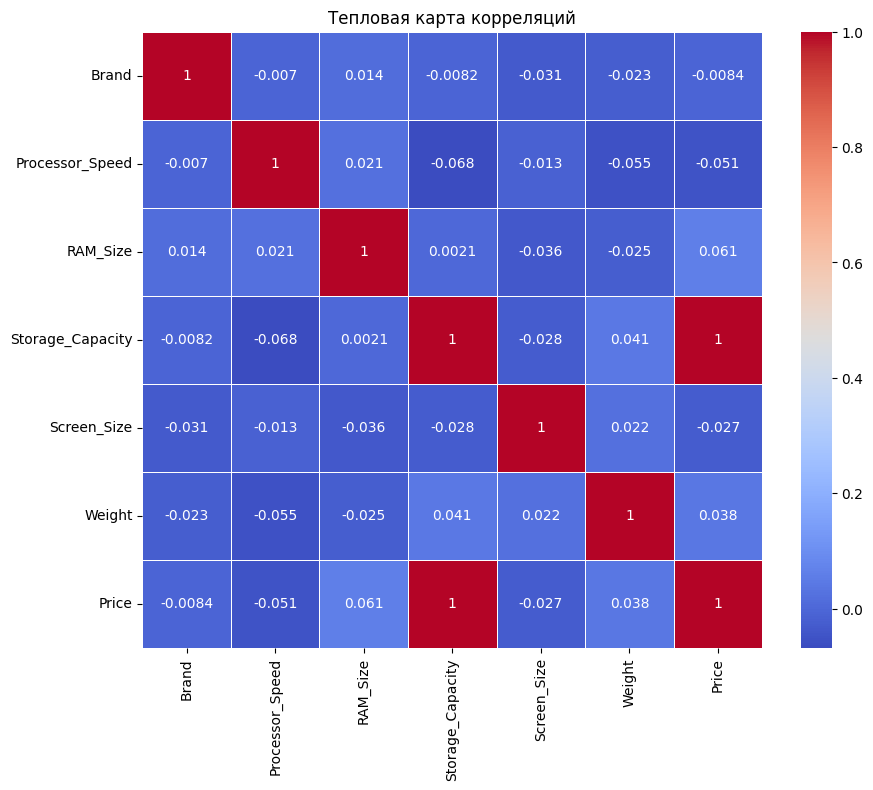

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Тепловая карта корреляций')
plt.show()

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

# Масштабирование

scaler = StandardScaler()

X = scaler.fit_transform(X)

# Разделение выборки

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('\nРазмер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)



Размер обучающей выборки: (800, 6)
Размер тестовой выборки: (200, 6)


In [ ]:
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=2000,
    random_state=42
)

In [ ]:
history = model.fit(X_train, y_train)

print('\nМодель обучена.')


Модель обучена.


In [ ]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Real Price': y_test,
    'Predicted Price': y_pred
})

print('\nПервые прогнозы:')
print(results.head(10))


Первые прогнозы:
       Real Price  Predicted Price
521  10900.502075     10639.571146
737  31727.516697     31558.295253
740   9636.022750      9534.642169
660   9412.599857      9428.479252
411  31641.105861     32003.056090
678  31832.486943     31679.954992
626  10438.451568     10664.250610
513  17205.205679     16959.278219
859  18743.569392     18496.674089
136  32342.705862     32386.877355


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print('\nМетрики качества модели:')

print(f'MAE  = {mae:.2f}')
print(f'MSE  = {mse:.2f}')
print(f'RMSE = {rmse:.2f}')
print(f'R2   = {r2:.4f}')


Метрики качества модели:
MAE  = 152.50
MSE  = 34921.83
RMSE = 186.87
R2   = 0.9996


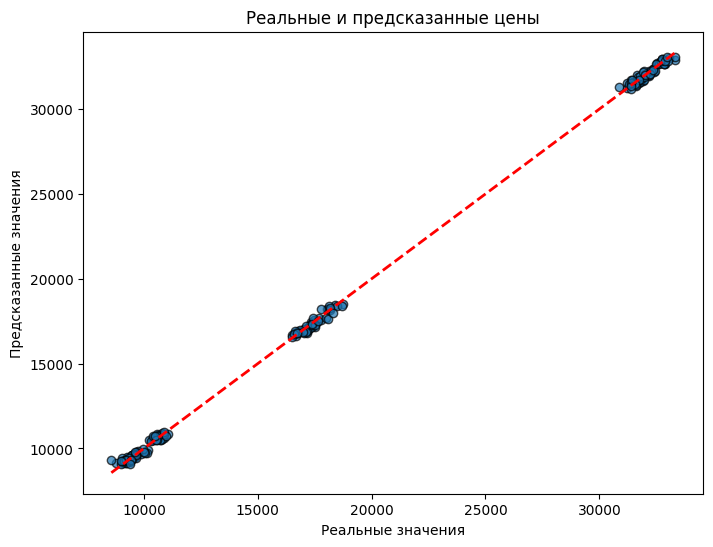

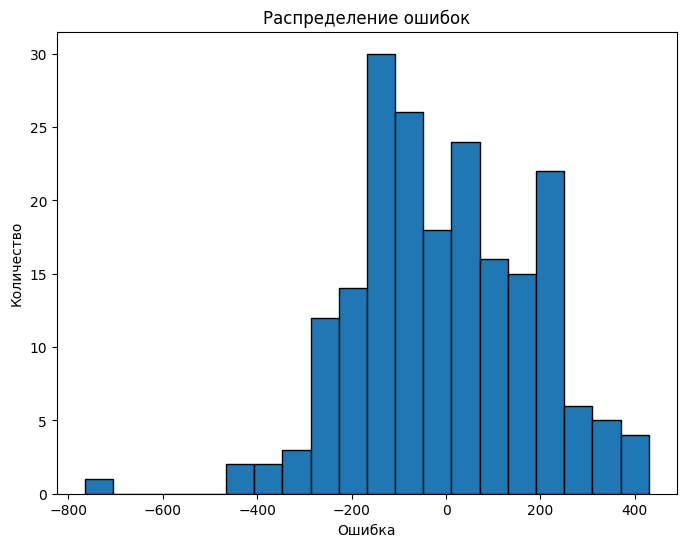

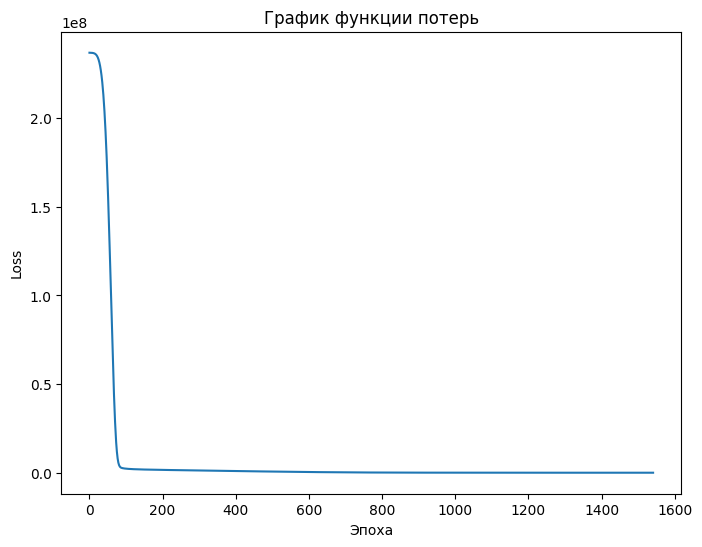


Важность признаков:
            Feature  Importance
3  Storage_Capacity    0.478969
4       Screen_Size    0.171474
2          RAM_Size    0.167996
0             Brand    0.123385
1   Processor_Speed    0.116904
5            Weight    0.111974


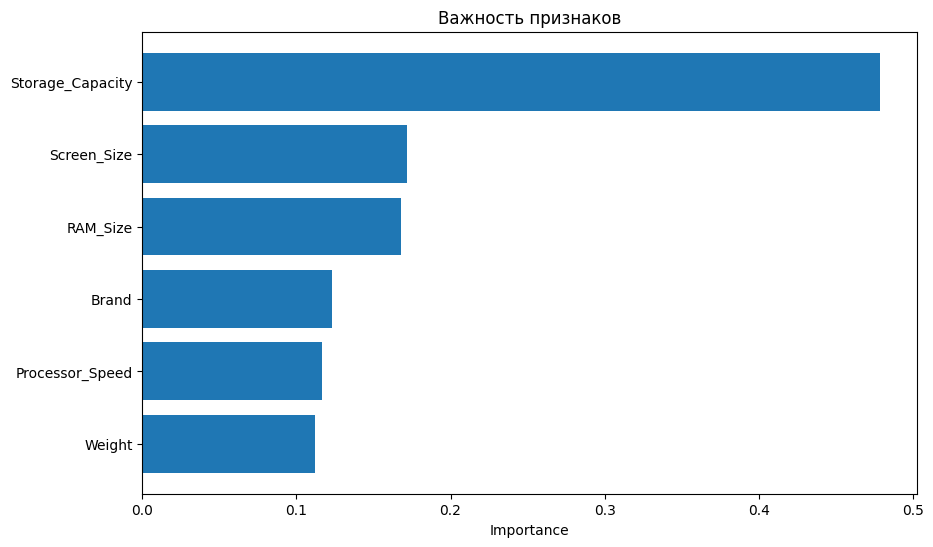

\nВывод:
MLP-регрессор успешно обучен.
Модель показывает способность прогнозировать цены ноутбуков.
Оценка качества выполнена с помощью MAE, MSE, RMSE и R2.


In [ ]:
# ---------------------------------------------------------
# График реальных и предсказанных значений
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    edgecolors='black'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')

plt.title('Реальные и предсказанные цены')

plt.show()

# ---------------------------------------------------------
# Гистограмма ошибок
# ---------------------------------------------------------

errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(
    errors,
    bins=20,
    edgecolor='black'
)

plt.title('Распределение ошибок')
plt.xlabel('Ошибка')
plt.ylabel('Количество')

plt.show()

# ---------------------------------------------------------
# График потерь
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(model.loss_curve_)

plt.title('График функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')

plt.show()

# =========================================================
# 12. ВАЖНОСТЬ ПРИЗНАКОВ
# =========================================================

feature_names = [
    'Brand',
    'Processor_Speed',
    'RAM_Size',
    'Storage_Capacity',
    'Screen_Size',
    'Weight'
]

importance = np.abs(model.coefs_[0]).mean(axis=1)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print('\nВажность признаков:')
print(importance_df)

# ---------------------------------------------------------
# График важности признаков
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Важность признаков')

plt.xlabel('Importance')

plt.show()

# =========================================================
# 13. ВЫВОД
# =========================================================

print('\\nВывод:')

print('MLP-регрессор успешно обучен.')
print('Модель показывает способность прогнозировать цены ноутбуков.')
print('Оценка качества выполнена с помощью MAE, MSE, RMSE и R2.')